# extract velocities from CautoRIFT outputs at lon/lat points

### Requirements:
### - folder containing velocity outputs from CautoRIFT workflow
### - csv containing lon lat coordinates

## import libraries

In [1]:
import numpy as np
import pandas as pd
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import rasterio
import rasterio.plot
from pyproj import Proj, Transformer
import glob
from scipy.spatial import KDTree
from pyproj import Proj, transform

## modify inputs

In [2]:
#inputs - WOLVERINE

#path to cautorift outputs
cautorift_path = '/Users/lindsaysummers/Documents/Research/Cautorift/Results_240m/CrossPlatform/Wolverine/'

#path to csv with lon/lat points along centerline
points_path = '/Users/lindsaysummers/Documents/Research/Velocity/Wolverine/RGI_data/'
points_name = 'centerline_points_latlon_0.5km_spacing.csv'

#where to store extracted cautorift velocities
out_path = '/Users/lindsaysummers/Documents/Research/Cautorift/Results_240m/'

## function to extract pixel value from band 3 in cautorift outputs

In [3]:
def get_velocity(image, lon, lat, band):
  """
  extract a pixel value from a specific band at a lat/lon point

  Arguments:
  image (str): The path to the GeoTIFF file
  lat (float): The latitude of the point
  lon (float): The longitude of the point
  band (int): The band number (starting from 1)

  Returns:
  float: The pixel value at the specified location and band, or None if the location is outside the image bounds
  """
  try:
    with rasterio.open(image) as src:
        #get CRS of the GeoTIFF
        src_crs = src.crs

        #create transformer to convert from lat/lon to the GeoTIFF's CRS
        transformer = Transformer.from_crs("epsg:4326", src_crs, always_xy=True)
        x, y = transformer.transform(lon, lat)

        #double check that point is within image bounds
        if not (src.bounds.left <= x <= src.bounds.right and src.bounds.bottom <= y <= src.bounds.top):
            print(f"Coordinates ({lon}, {lat}) are outside the image bounds.")
            return None

        #transform the coordinates to pixel coordinates
        py, px = src.index(x, y)

        #read value from the specified band
        #band 3 in cautorift
        value = src.read(band)[py, px] #read entire band then access the pixel

        return value

  except rasterio.errors.RasterioIOError as e:
      print(f"Error opening the GeoTIFF file: {e}")
      return None
  except Exception as e:
      print(f"An unexpected error occurred: {e}")
      return None

## import coordinates

In [4]:
#import csv containing lat lon points
points_list = pd.read_csv(os.path.join(points_path, points_name))
points_list = points_list.values.tolist()

#dictionary to store points
points = {}

for pt in range(len(points_list)):
    points[pt+1] = points_list[pt]
    print(f'point {pt+1} added to points directory')

point 1 added to points directory
point 2 added to points directory
point 3 added to points directory
point 4 added to points directory
point 5 added to points directory
point 6 added to points directory
point 7 added to points directory
point 8 added to points directory
point 9 added to points directory
point 10 added to points directory
point 11 added to points directory
point 12 added to points directory
point 13 added to points directory
point 14 added to points directory


## extract velocities

In [5]:
#locate cautorift outputs
cautorift_outputs = glob.glob(os.path.join(cautorift_path, 'velocity*.tif'))

#dictionary to store results
cautorift_velocities = {
    'mid_date': [],
    'date_dt': []
}

#add ptN keys to results dictionary
for pt_num in points:
    cautorift_velocities[f'pt{pt_num}'] = []

#loop through images
for image in cautorift_outputs:
    parts = image.split('_')
    start_date = datetime.strptime(parts[2], '%Y%m%d')
    end_date = datetime.strptime(parts[3], '%Y%m%d')
    mid_date = start_date + (end_date - start_date) / 2

    cautorift_velocities['mid_date'].append(mid_date.strftime('%Y%m%d'))
    cautorift_velocities['date_dt'].append((end_date - start_date).days)

    #loop through points and store velocity values
    for pt_num, (lon, lat) in points.items():
        band = 3  # adjust if needed
        velocity = get_velocity(image, lon, lat, band)
        cautorift_velocities[f'pt{pt_num}'].append(velocity)

# Convert results to DataFrame
cautorift_velocities_df = pd.DataFrame(cautorift_velocities)

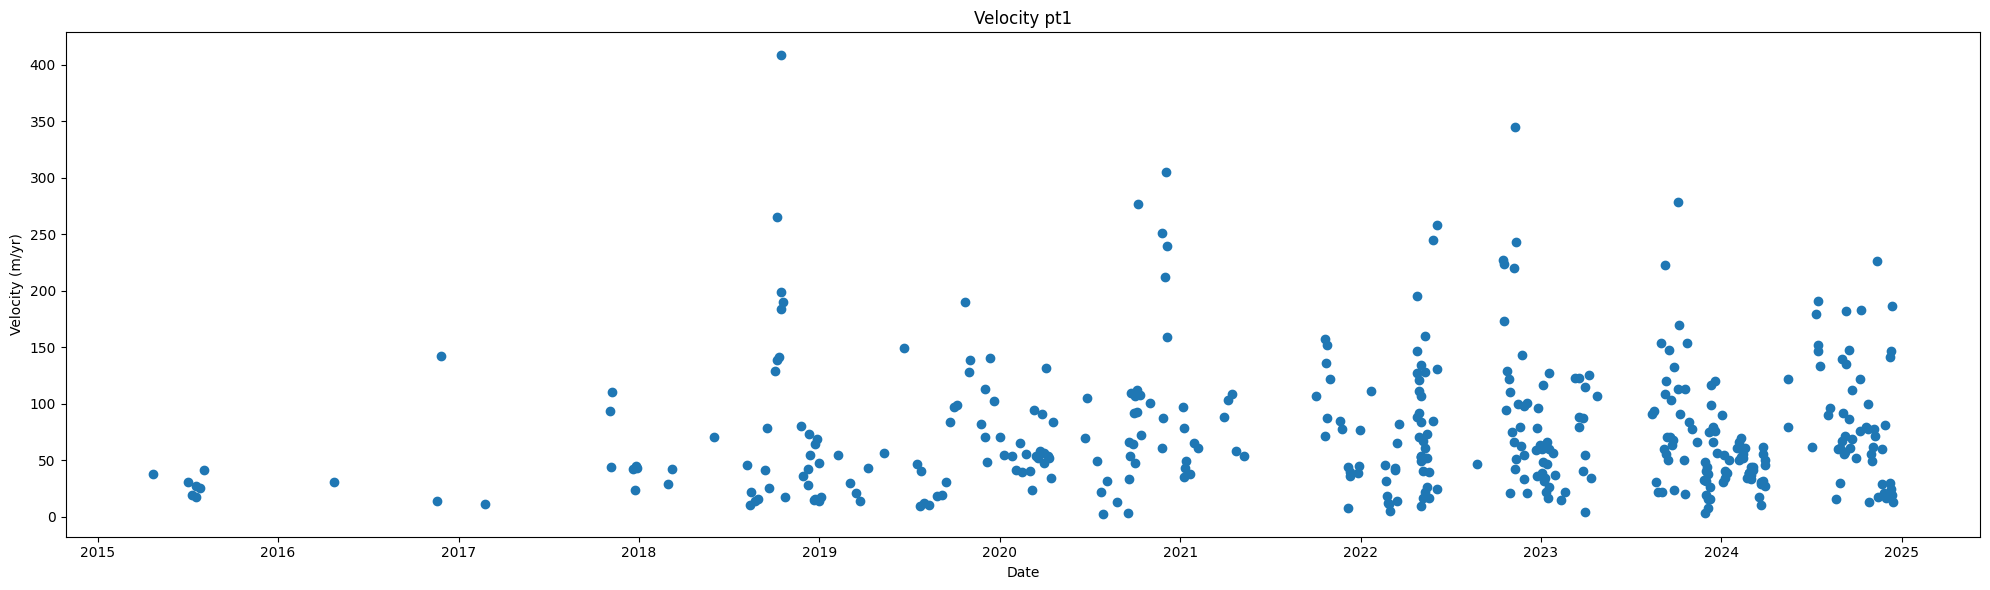

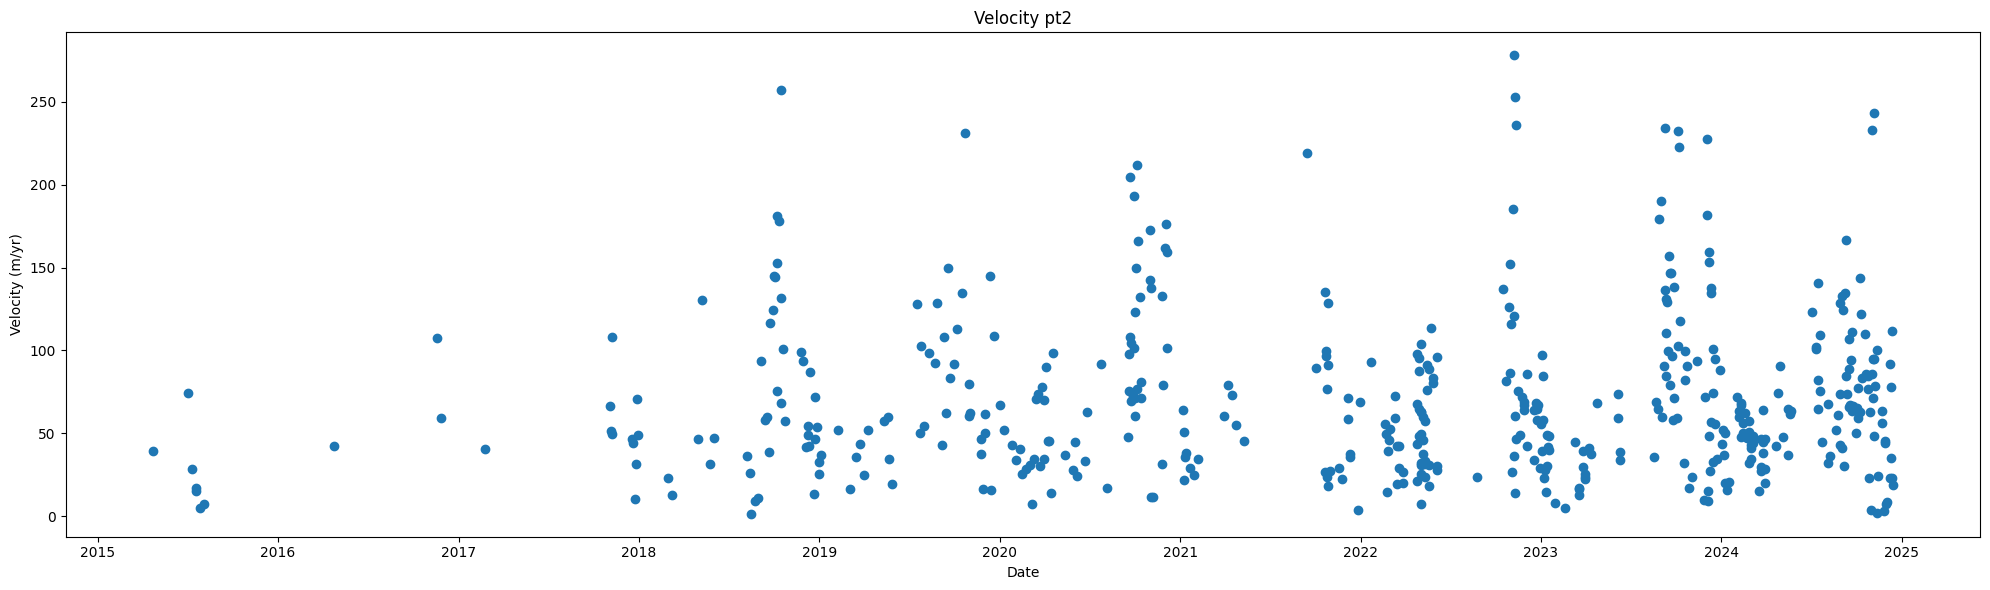

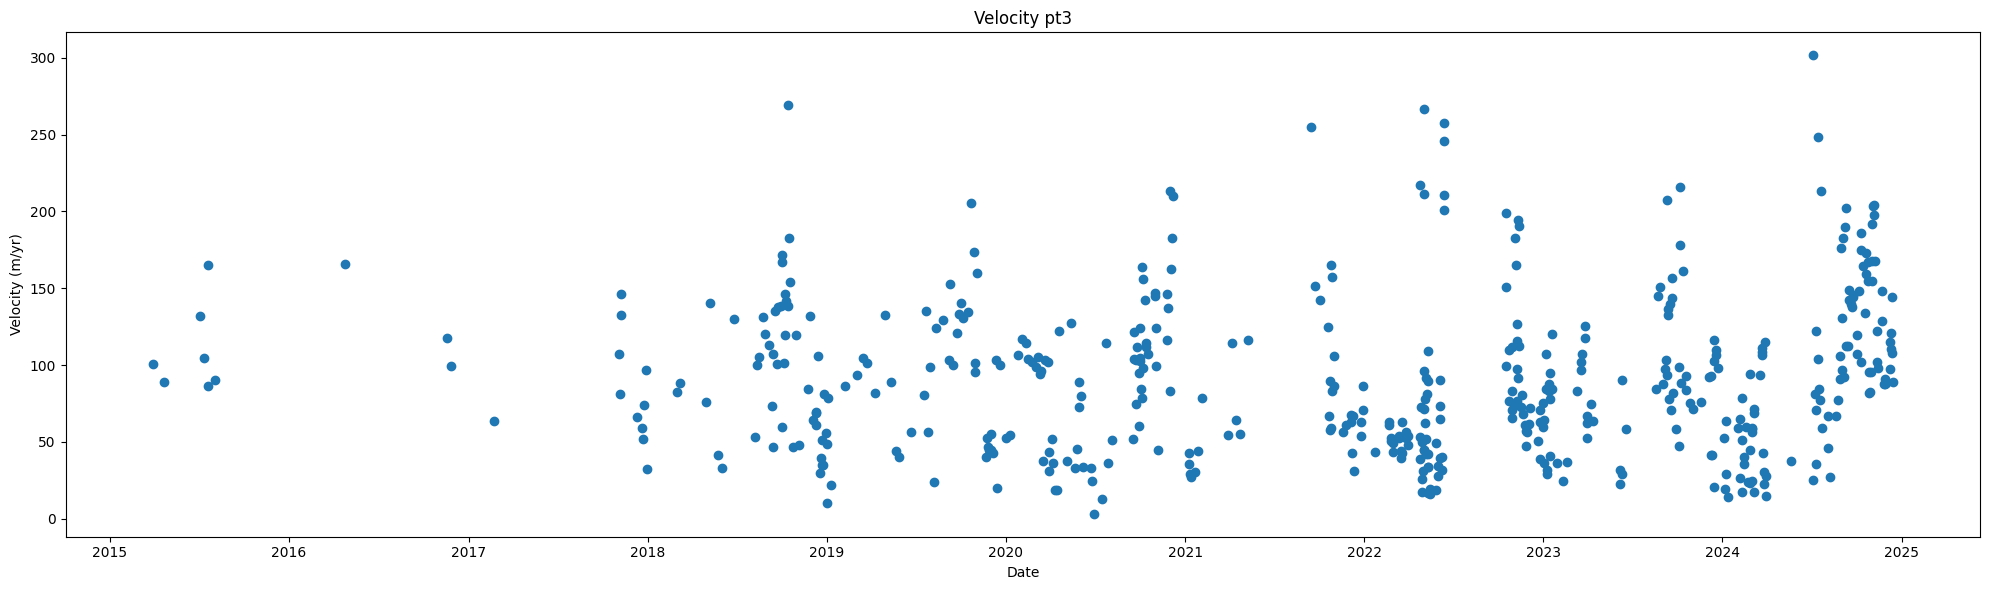

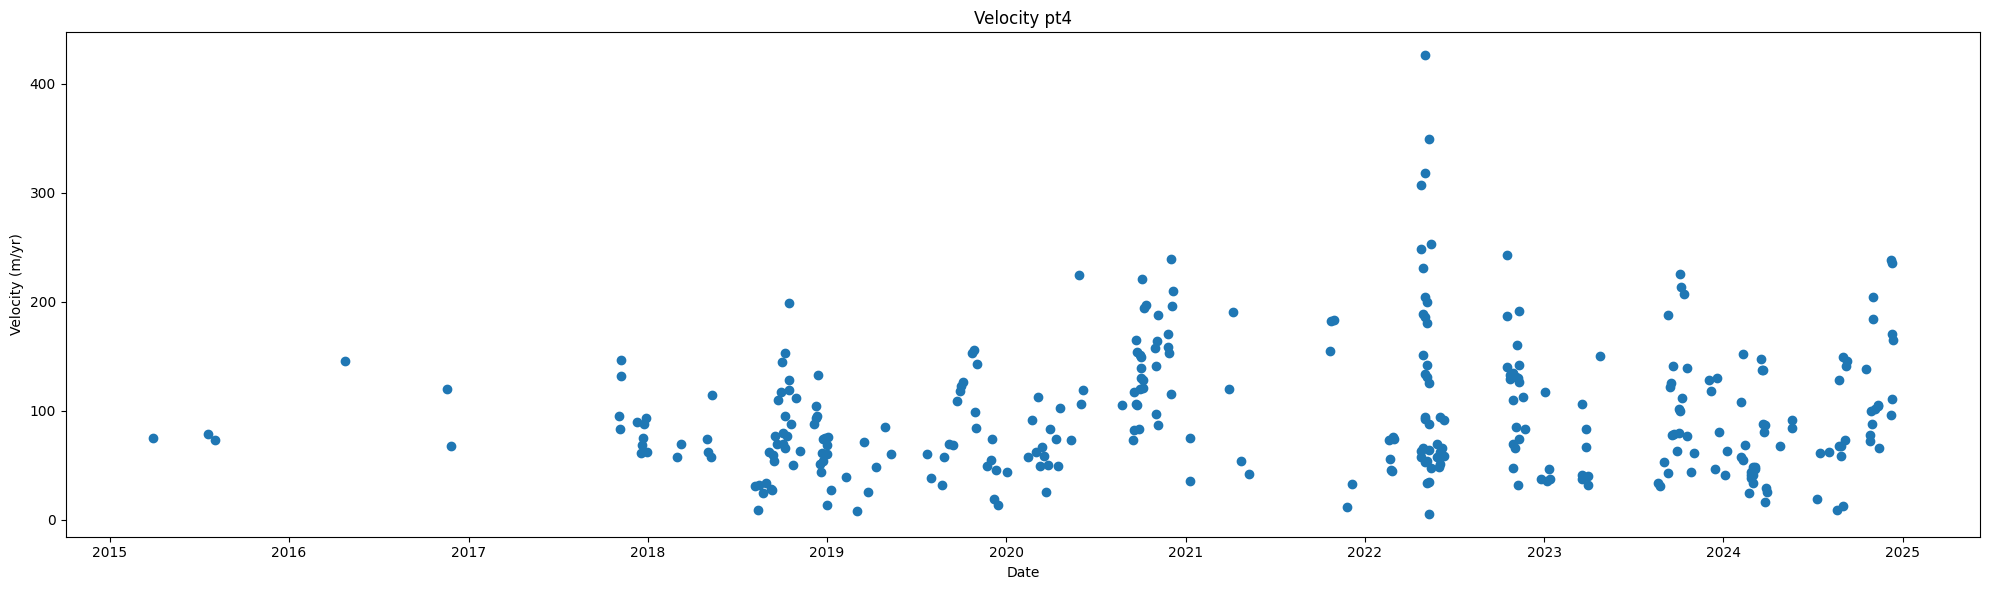

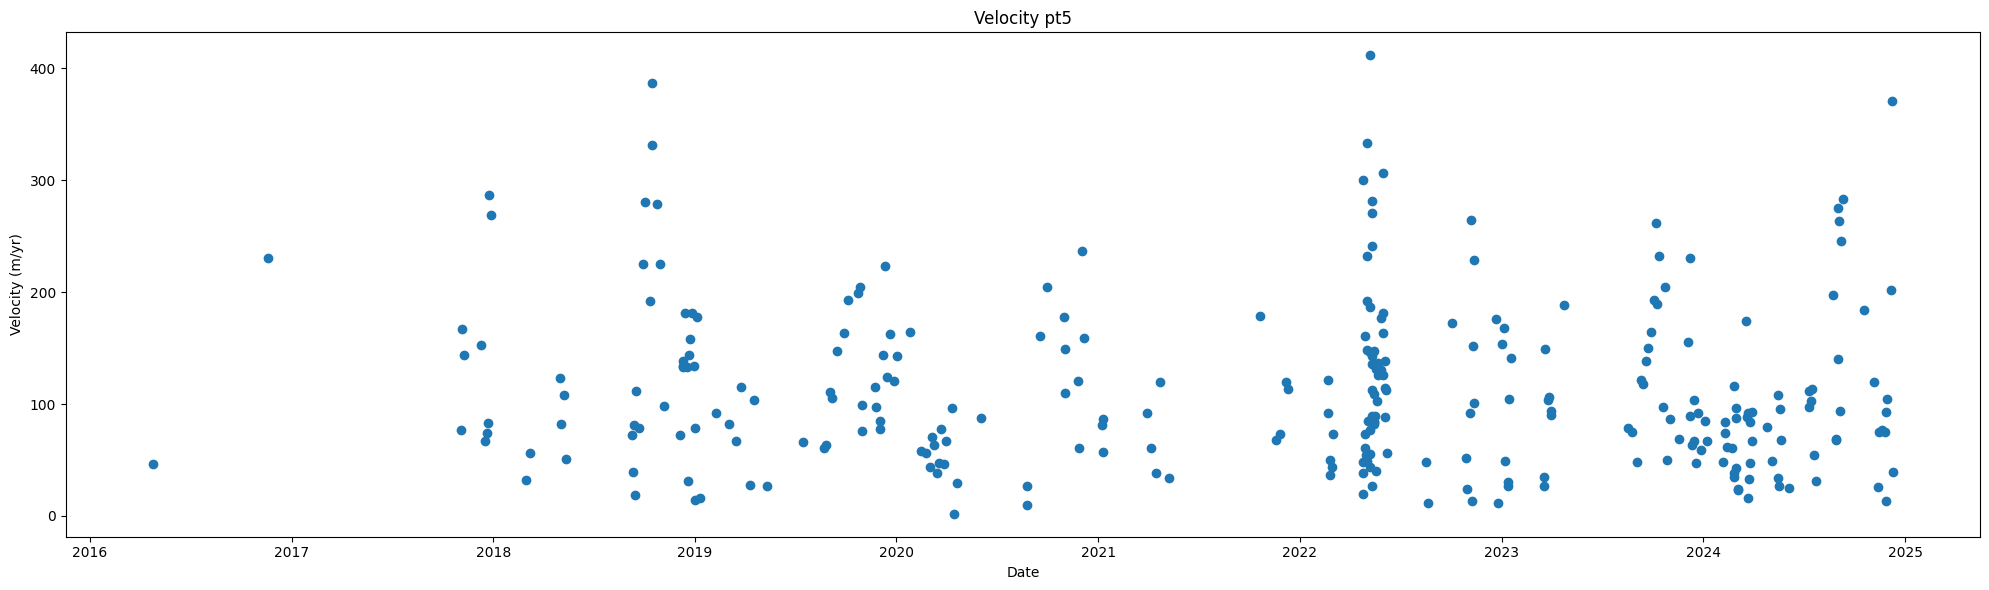

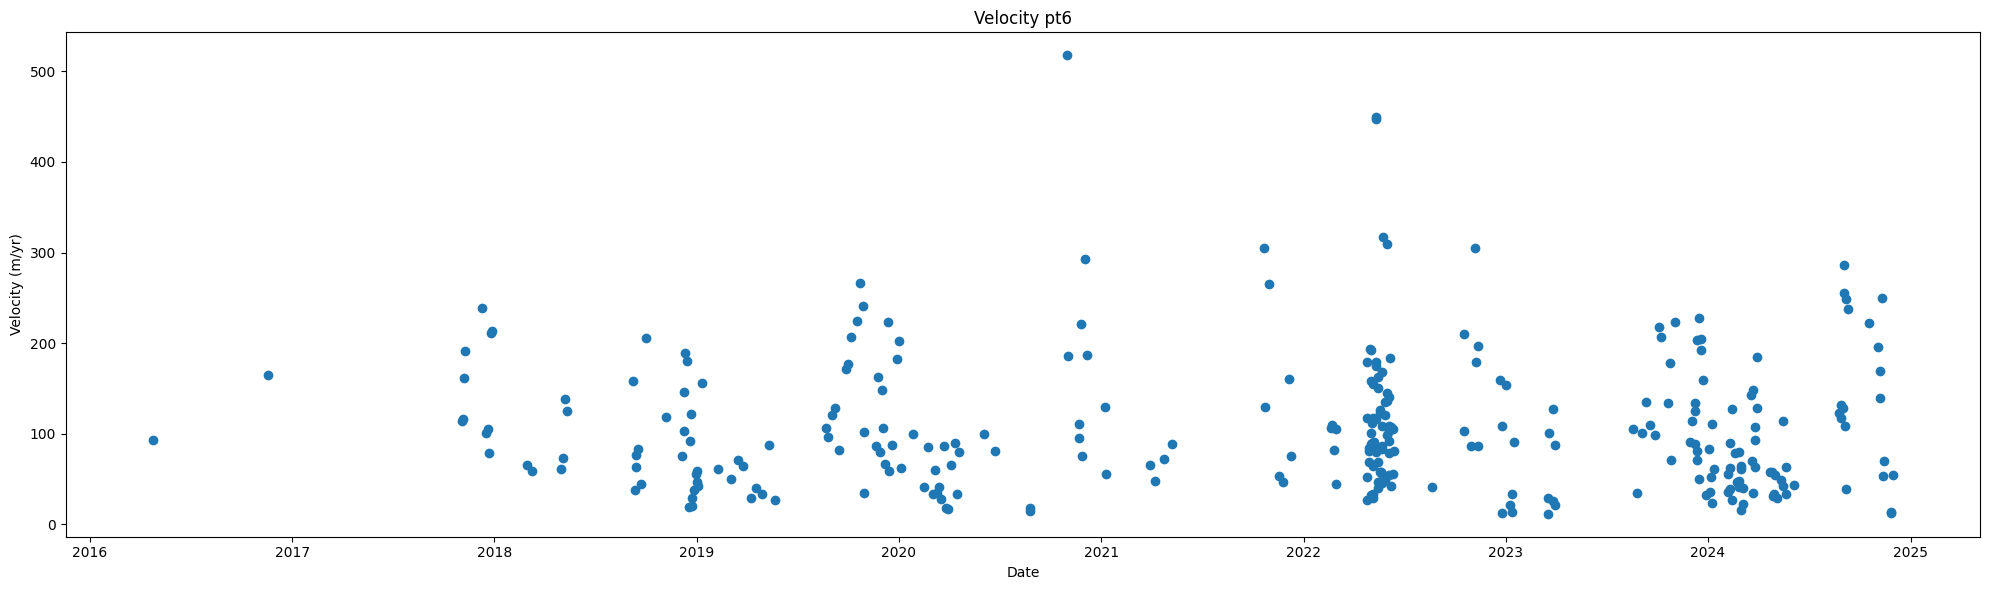

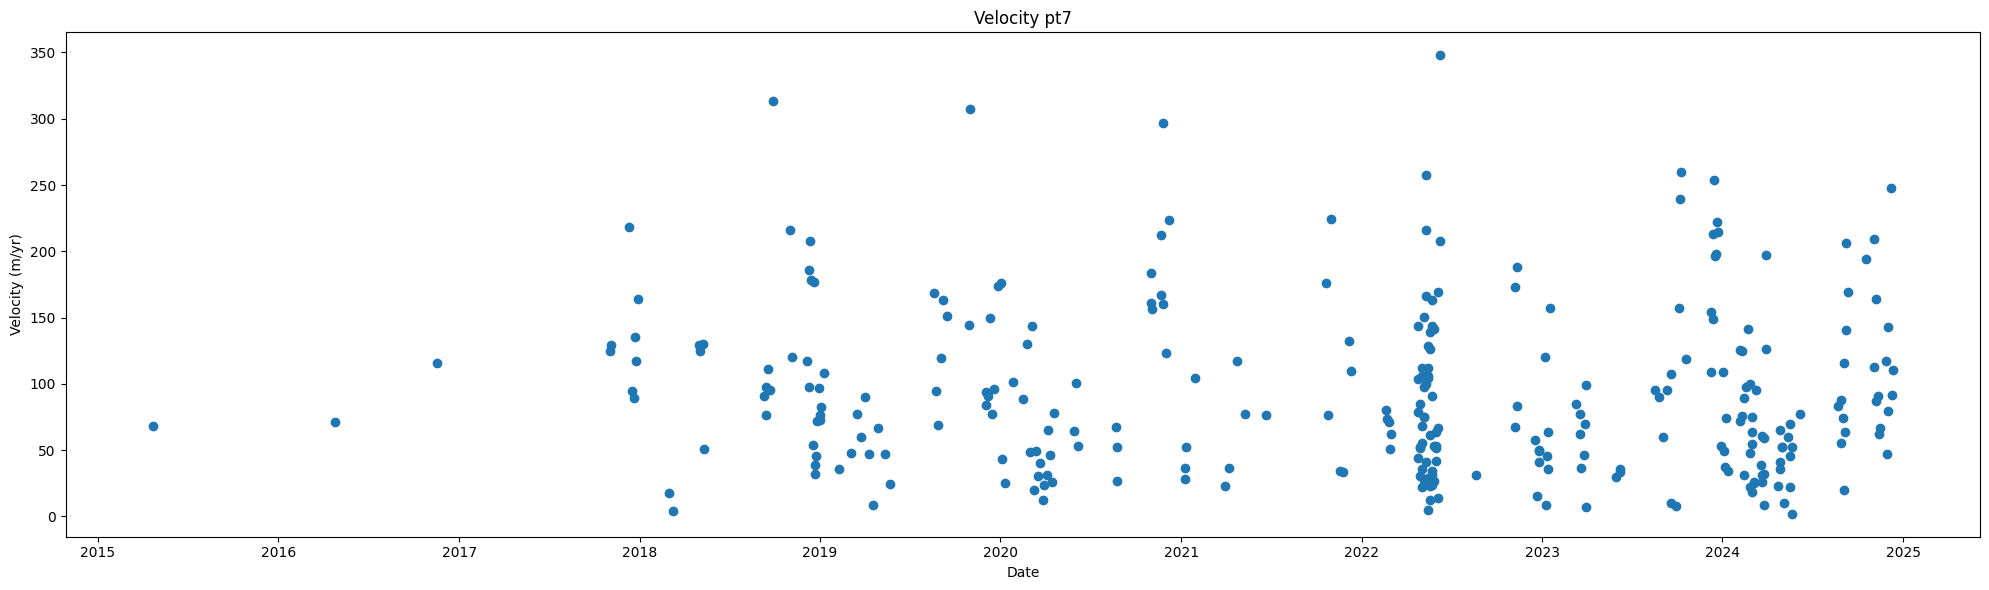

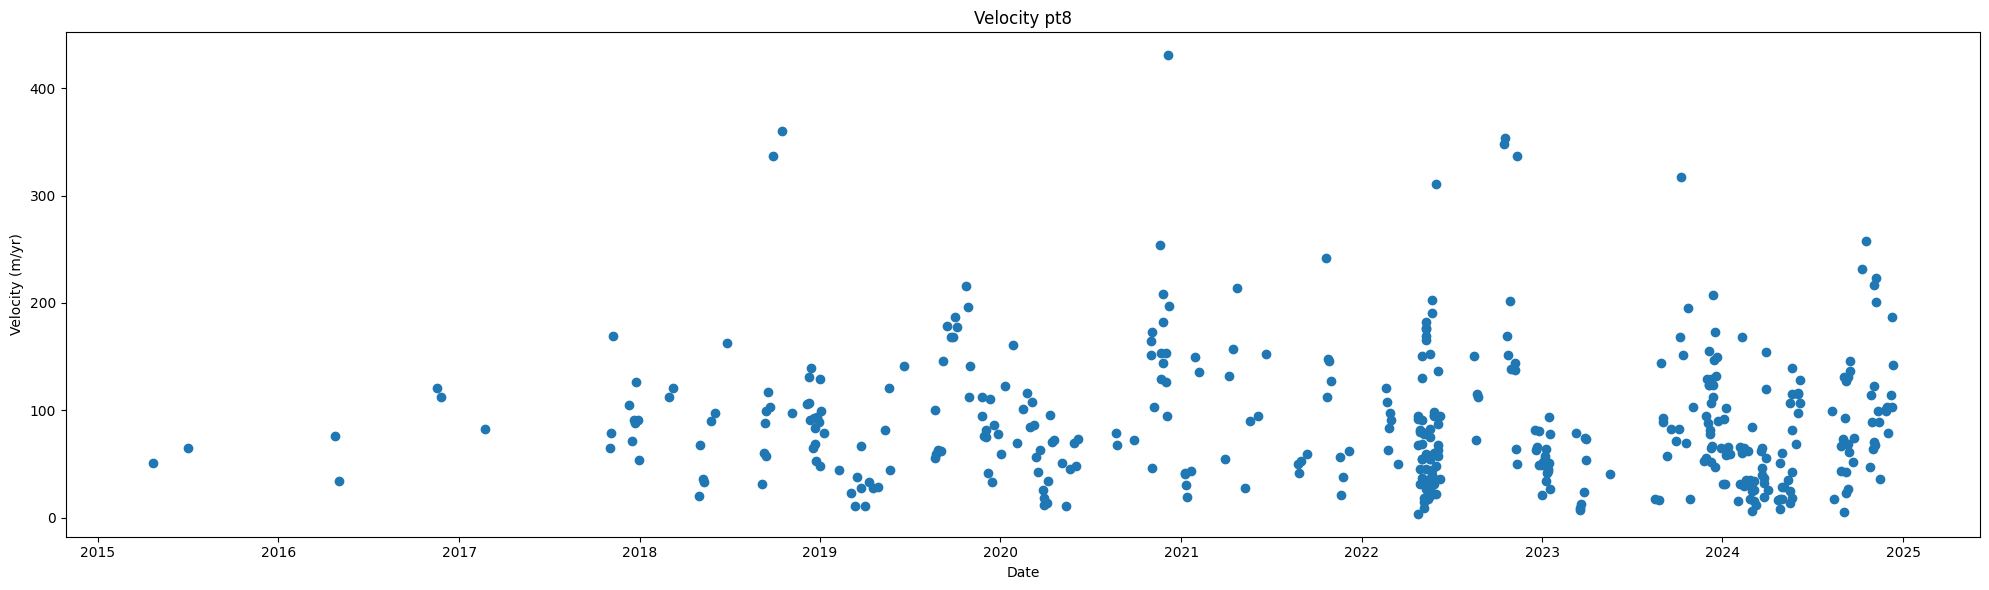

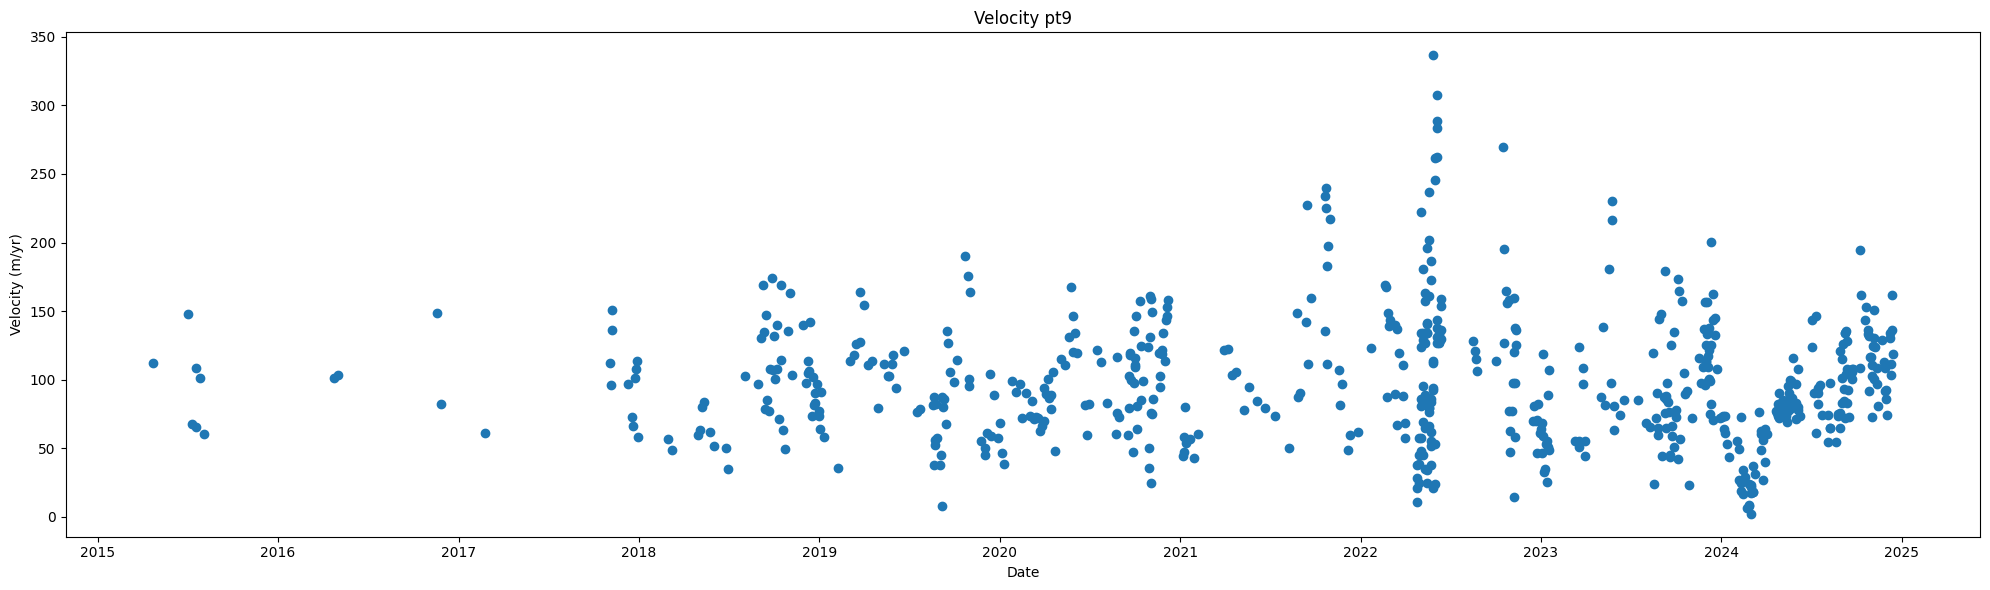

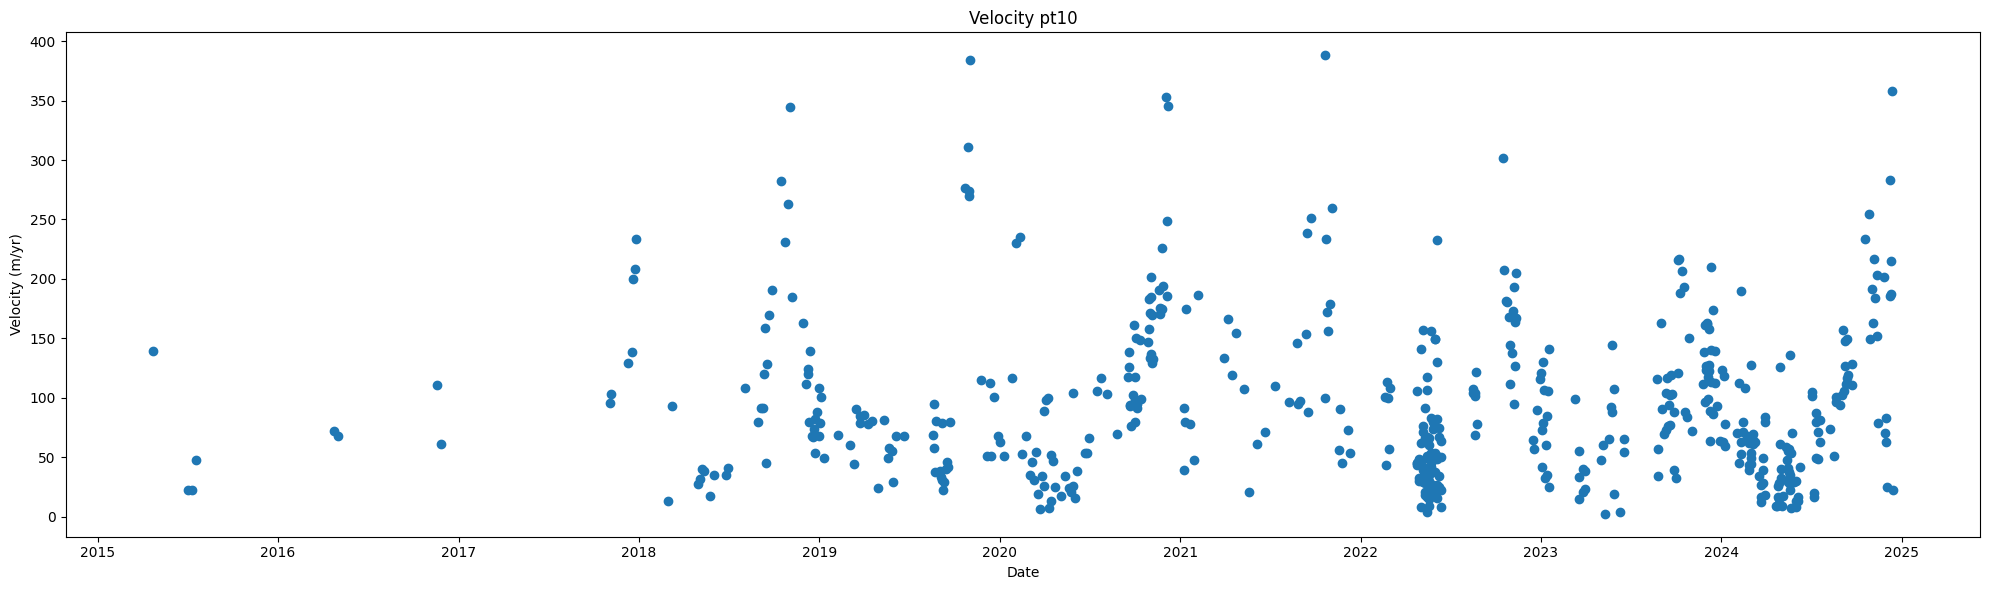

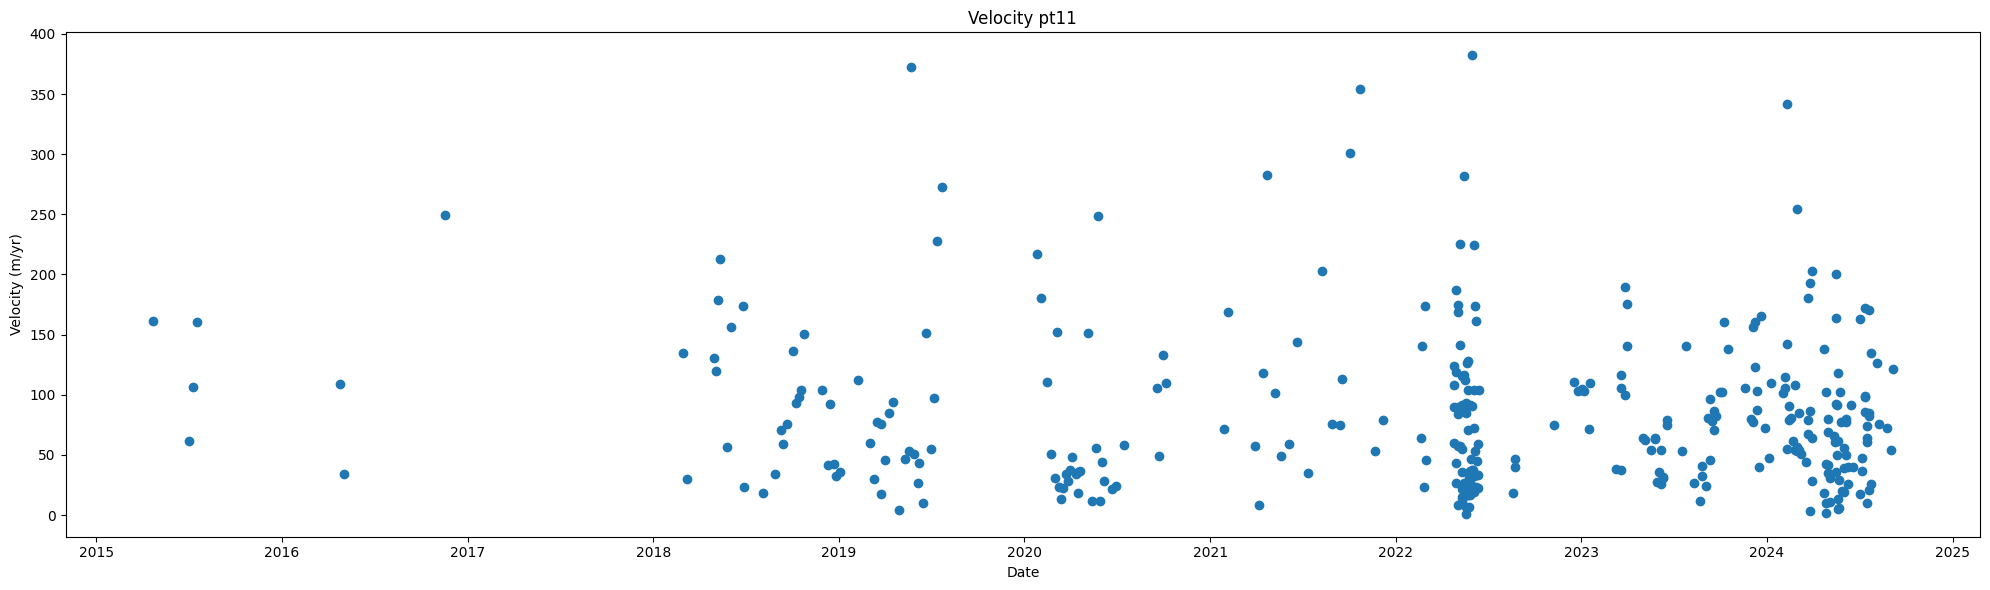

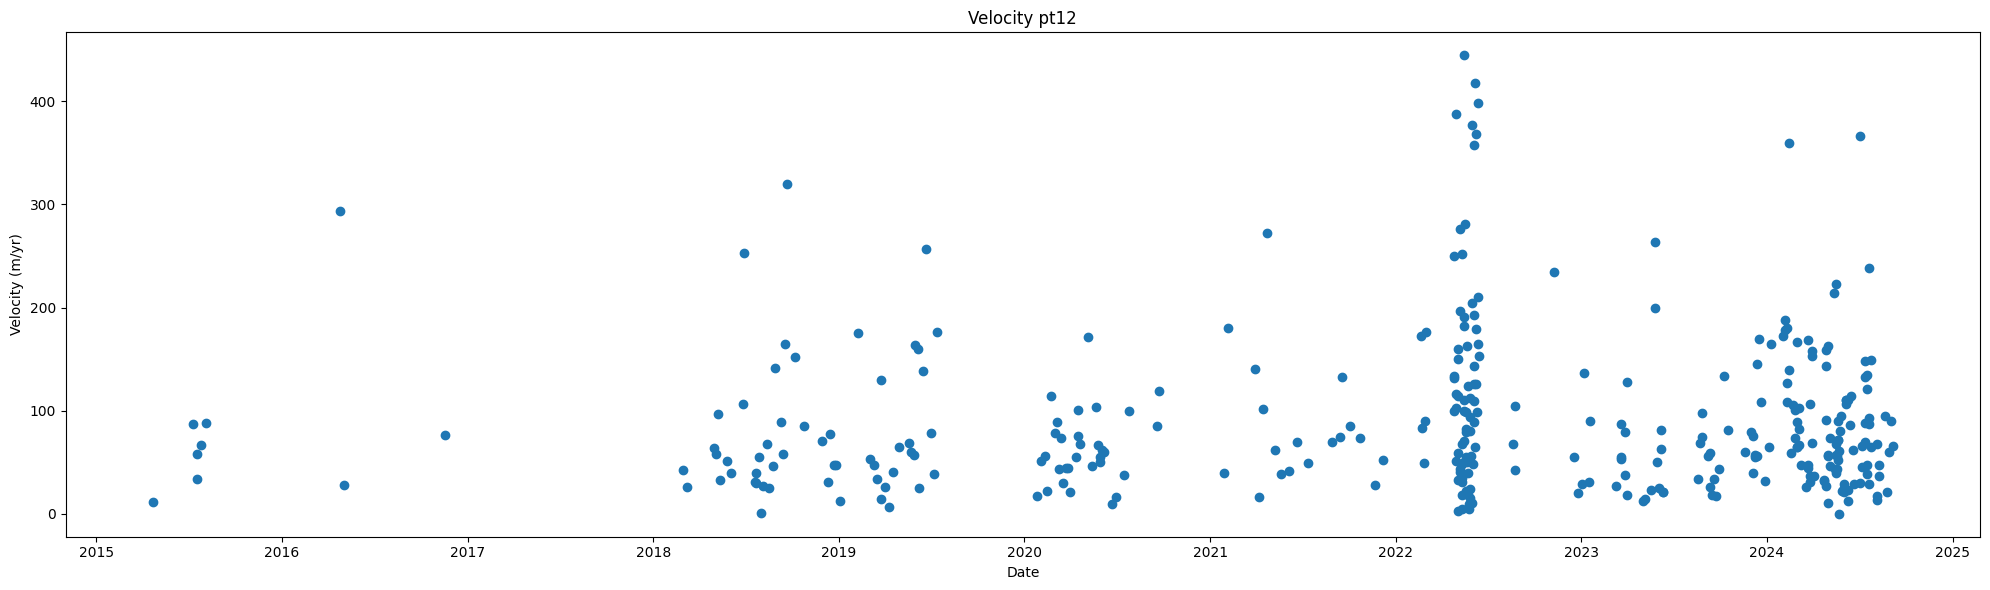

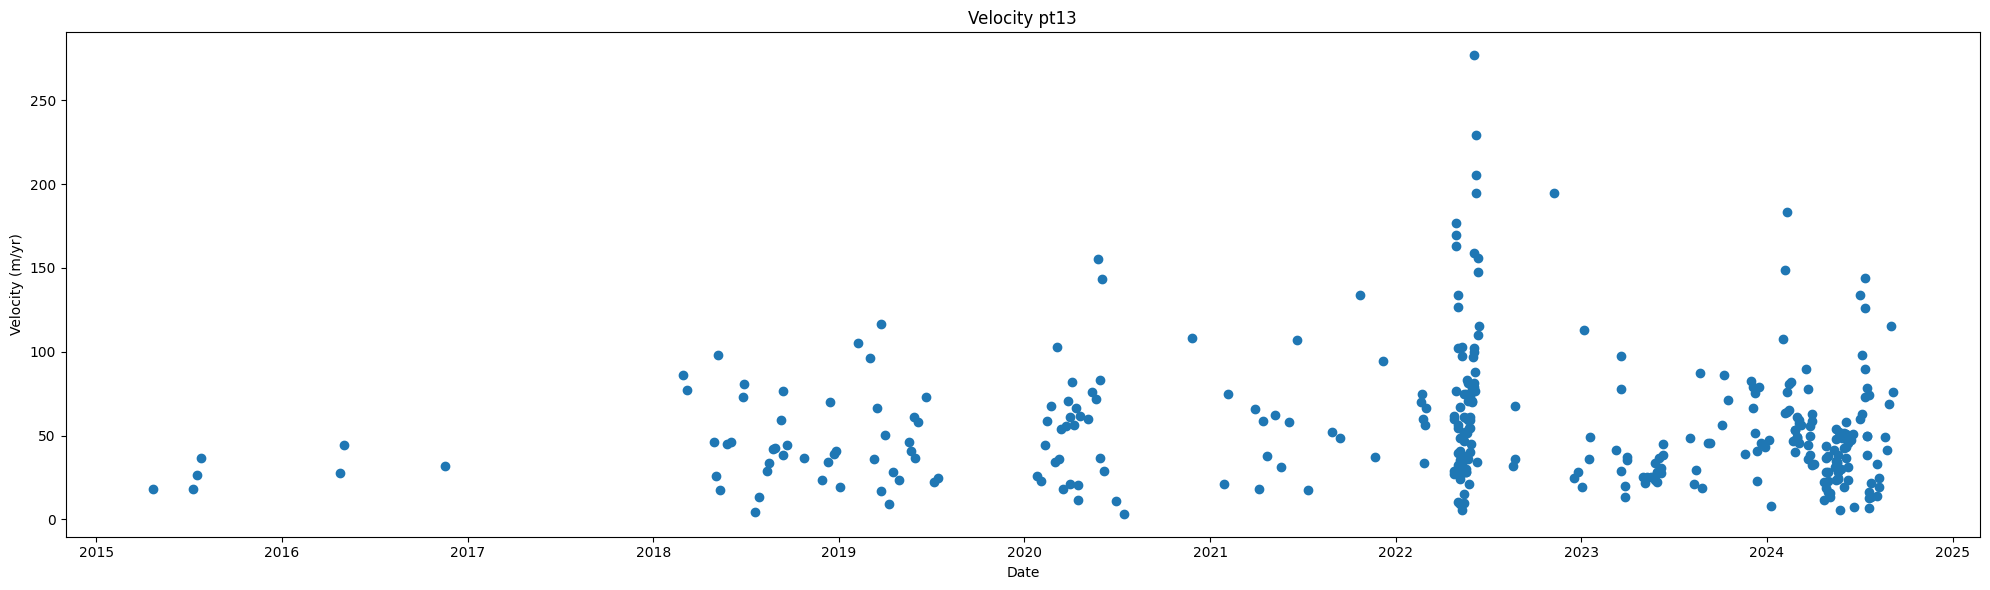

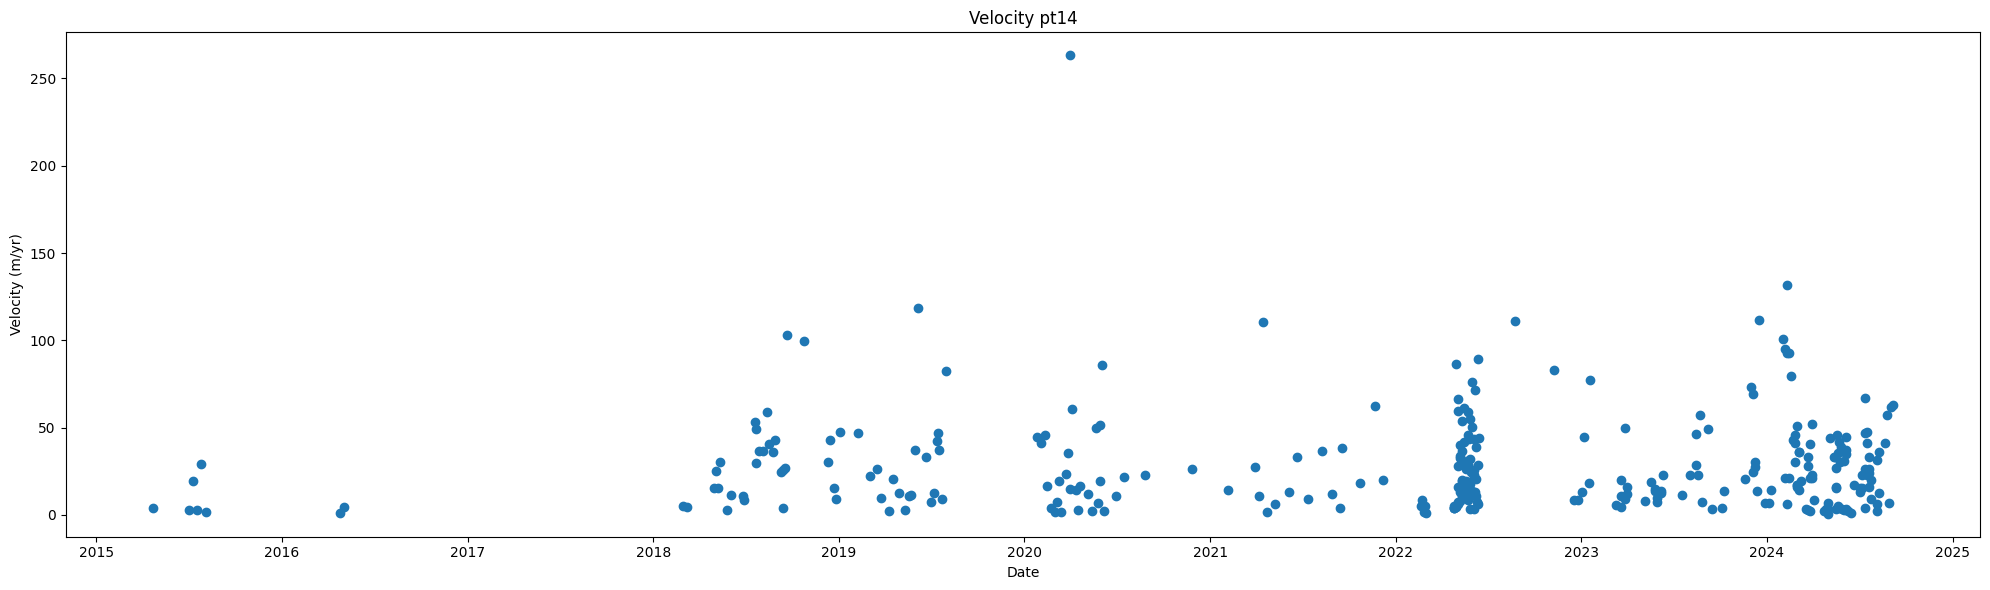

In [6]:
#convert mid_date to datetime format for plotting
cautorift_velocities_df['mid_date_dt'] = pd.to_datetime(cautorift_velocities_df['mid_date'], format='%Y%m%d')

#locate point columns
point_cols = [col for col in cautorift_velocities_df.columns if col.startswith('pt')]

for pt_col in point_cols:
    plt.figure(figsize=(20, 6))
    plt.scatter(cautorift_velocities_df['mid_date_dt'], cautorift_velocities_df[pt_col], marker='o', linestyle='-')
    plt.title(f'Velocity {pt_col}')
    plt.xlabel('Date')
    plt.ylabel('Velocity (m/yr)')
    plt.tight_layout()
    plt.show()

## export results

In [7]:
cautorift_velocities_df.to_csv(f'{out_path}cautorift_velocities.csv', index=False)